# Run FilterZyme on sequences form Yang et al. 

## Prep input data

In [31]:
import pandas as pd
import numpy as np
import re

def clean_sequence(seq: str) -> str:

    if pd.isna(seq):
        return None
    seq = seq.upper()
    seq = re.sub(r'[^ACDEFGHIKLMNPQRSTVWY]', '', seq)  # Keep only standard 20 amino acids
    return seq

# Load sequence and Activity data from Yang et al. 
# sequence_Activity_data = pd.read_excel("Yangetal_Experimental_results_tabulation.xlsx", sheet_name=None)

# Process CuSOD data
round1_CuSOD = sequence_Activity_data['round1_CuSOD']
round1_CuSOD['round'] = 'round1'
round2_CuSOD = sequence_Activity_data['round2_CuSOD']
round2_CuSOD = round2_CuSOD.iloc[:, :-5]
round2_CuSOD['round'] = 'round2'
round3_CuSOD = sequence_Activity_data['round3_CuSOD']
round3_CuSOD = round3_CuSOD.iloc[:, :-5]
round3_CuSOD['round'] = 'round3'

for df_name, df in (("r1", round1_CuSOD), ("r2", round2_CuSOD), ("r3", round3_CuSOD)):
    df.columns = df.columns.astype(str).str.strip()
    df.columns = df.columns.str.replace(r'\s+', ' ', regex=True)
    # keep first occurrence of any duplicated column label
    df = df.loc[:, ~df.columns.duplicated()]
    if df_name == "r1":
        round1_MDH = df
    elif df_name == "r2":
        round2_MDH = df
    else:
        round3_MDH = df

CuSOD_all_rounds = pd.concat([round1_CuSOD, round2_CuSOD, round3_CuSOD], ignore_index=True)

# Process MDH data
round1_MDH = sequence_Activity_data['round1_MDH']
round1_MDH['round'] = 'round1'
round2_MDH = sequence_Activity_data['round2_MDH']
round2_MDH = round2_MDH.iloc[:, :-5]
round2_MDH['round'] = 'round2'  
round3_MDH = sequence_Activity_data['round3_MDH']
round3_MDH = round3_MDH.iloc[:, :-5]
round3_MDH['round'] = 'round3'

for df_name, df in (("r1", round1_MDH), ("r2", round2_MDH), ("r3", round3_MDH)):
    df.columns = df.columns.astype(str).str.strip()
    df.columns = df.columns.str.replace(r'\s+', ' ', regex=True)
    # keep first occurrence of any duplicated column label
    df = df.loc[:, ~df.columns.duplicated()]
    if df_name == "r1":
        round1_MDH = df
    elif df_name == "r2":
        round2_MDH = df
    else:
        round3_MDH = df

MDH_all_rounds = pd.concat([round1_MDH, round2_MDH, round3_MDH], ignore_index=True)

# Only consider purified proteins for Activity analysis
CuSOD_all_rounds = CuSOD_all_rounds[CuSOD_all_rounds['Purification'] == 'Y'].copy()
CuSOD_all_rounds = CuSOD_all_rounds.rename(columns={'Activity (5μg/mL)': 'Activity', "expressed sequence": "Sequence"})

MDH_all_rounds = MDH_all_rounds[MDH_all_rounds['Purification'] == 'Y'].copy()
MDH_all_rounds = MDH_all_rounds.rename(columns={'Activity (20 μg/mL)': 'Activity', "expressed sequence": "Sequence"})

# Add all necessary columns
CuSOD_all_rounds["enzyme"] = "CuSOD"
CuSOD_all_rounds['substrate_name'] = "superoxide_radical"
CuSOD_all_rounds['substrate_smiles'] = "[O-][O]" # Superoxide radical
CuSOD_all_rounds['cofactor_name'] = [[] for _ in range(len(CuSOD_all_rounds))]
CuSOD_all_rounds['cofactor_smiles'] = [[] for _ in range(len(CuSOD_all_rounds))]
CuSOD_all_rounds['substrate_moiety'] = None
CuSOD_all_rounds['cofactor_moiety'] = None

MDH_all_rounds["enzyme"] = "MDH"
MDH_all_rounds['substrate_name'] = "oxaloacetic_acid"
MDH_all_rounds['substrate_smiles'] ="O=C(O)C(=O)CC(=O)O" # Oxaloacetic acid
MDH_all_rounds['cofactor_name'] = "NADH"
MDH_all_rounds['cofactor_smiles'] = "C1C=CN(C=C1C(=O)N)[C@H]2[C@@H]([C@@H]([C@H](O2)COP(=O)(O)OP(=O)(O)OC[C@@H]3[C@H]([C@H]([C@@H](O3)N4C=NC5=C(N=CN=C54)N)O)O)O)O" # NADH
MDH_all_rounds['substrate_moiety'] = "O=C(C(=O)O)CC(=O)"  # Malonate moiety
MDH_all_rounds['cofactor_moiety'] = "NC(=O)[n+]1ccc(C)[CH-]1"  # Nicotinamide moiety

# Combine the filtered datasets
MDH_CuSOD_combined = pd.concat([CuSOD_all_rounds, MDH_all_rounds], ignore_index=True)
MDH_CuSOD_combined['Sequence'] = MDH_CuSOD_combined['Sequence'].apply(clean_sequence)
MDH_CuSOD_combined['Entry'] = (
    MDH_CuSOD_combined['Name'].astype(str) + "_" + MDH_CuSOD_combined['enzyme'].astype(str)
)
MDH_CuSOD_combined['Entry'] = MDH_CuSOD_combined['Entry'].str.replace('.', 'p', regex=False)
MDH_CuSOD_combined = MDH_CuSOD_combined[MDH_CuSOD_combined['Sequence'].str.len() <= 600].copy() # only enzymes shorter than 600 amino acids


# Round 3 data only
MDH_CuSOD_round3 = MDH_CuSOD_combined[MDH_CuSOD_combined['round'] == 'round3'].copy()
MDH_CuSOD_round3 = MDH_CuSOD_round3[MDH_CuSOD_round3['Sequence'].str.len() <= 600].copy() # only enzymes shorter than 600 amino acids

# MDH_CuSOD_combined.to_pickle('MDH_CuSOD_combined_input_df.pkl')
# MDH_CuSOD_round3.to_pickle('MDH_CuSOD_round3_input_df.pkl')

NameError: name 'sequence_Activity_data' is not defined

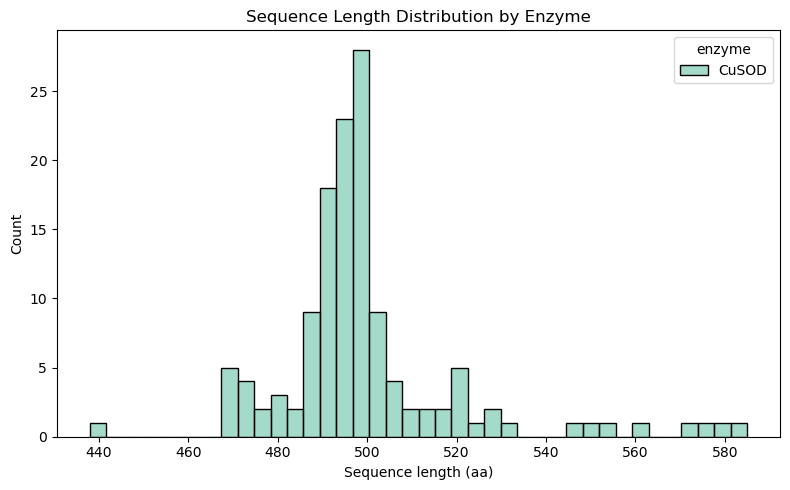

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

MDH_CuSOD_combined["seq_length"] = MDH_CuSOD_combined["Sequence"].str.len().astype(int)

plt.figure(figsize=(8,5))
sns.histplot(data=MDH_CuSOD_combined,
             x="seq_length",
             hue="enzyme",
             bins=40,
             kde=False,
             alpha=0.6,
             palette="Set2")
plt.xlabel("Sequence length (aa)")
plt.ylabel("Count")
plt.title("Sequence Length Distribution by Enzyme")
plt.tight_layout()
plt.show()



## Analyze filterzyme results

In [1]:
import pandas as pd
import seaborn as sns
# import plotting_utils as pu
import sys

sys.path.insert(0, '/nvme2/helen/EnzymeStructuralFiltering/')
import filterzyme
from filterzyme.utils.helpers import clean_plt

pastel_blue = "#aec7e8"
PALETTE_grey_blue = sns.blend_palette(["darkgrey", pastel_blue], as_cmap=True)


results_df = pd.read_pickle('/nvme2/helen/EnzymeStructuralFiltering/benchmarking/serine_hydrolases/filterzyme_output_yang_benchmark/geometricfiltering/structural_features_final.pkl')

boltz_only =  results_df[results_df['tool'] == 'boltz']
chai_only = results_df[results_df['tool'] == 'chai']
first_only = results_df[results_df['is_first'] == True]

Activity_map = dict(zip(results_df['Entry'], results_df['Activity']))
results_df_avg_all = results_df.groupby("Entry", as_index=False).mean(numeric_only=True)
results_df_std_all = results_df.groupby("Entry", as_index=False).std(numeric_only=True) #standard deviations of means of all structures per entry
results_df_avg_all['Activity'] = results_df_avg_all['Entry'].map(Activity_map)
results_df_std_all['Activity'] = results_df_std_all['Entry'].map(Activity_map)
results_df_avg_all["Activity"] = results_df_avg_all["Activity"].map({"Y":1, "N":0})
results_df_avg_all["Activity"] = pd.to_numeric(results_df_avg_all["Activity"], errors="coerce")
results_df_avg_all["Activity"] = (
    results_df_avg_all["Activity"].astype("category")
)



results_df_feature_means = results_df_avg_all.drop(columns=["Entry", "Activity"]).mean()
results_df_feature_stds  = results_df_std_all.drop(columns=["Entry", "Activity"]).mean() # Average standard deviations across entries

results_df_std_all_by_Activity = results_df_std_all.groupby("Activity",  as_index=False).mean(numeric_only=True)

In [2]:
results_df['Activity'].value_counts()

Activity
Y    927
N    252
Name: count, dtype: int64

In [3]:
feature_columns = [
'chai-chai_mean_proteinRMSD',
'chai-chai_std_proteinRMSD',
'boltz-chai_mean_proteinRMSD',
'boltz-chai_std_proteinRMSD',
'boltz-boltz_mean_proteinRMSD',
'boltz-boltz_std_proteinRMSD',
'entry_overall_mean_proteinRMSD',
'entry_overall_std_proteinRMSD',
'chai_aggregate_score',
'chai_ptm',
'chai_iptm',
'boltz2_confidence_score',
'boltz2_ptm',
'boltz2_iptm',
'boltz2_ligand_iptm',
'boltz2_protein_iptm',
'boltz2_complex_plddt',
'boltz2_complex_iplddt',
'boltz2_complex_pde',
'boltz2_complex_ipde',
'boltz2_affinity_pred_value',
'boltz2_affinity_probability_binary',
'boltz2_affinity_pred_value1',
'boltz2_affinity_probability_binary1',
'boltz2_affinity_pred_value2',
'boltz2_affinity_probability_binary2',
'boltz_boltz_mean_ligandRMSD',
'boltz_boltz_std_ligandRMSD',
'boltz_chai_mean_ligandRMSD',
'boltz_chai_std_ligandRMSD',
'chai_chai_mean_ligandRMSD',
'chai_chai_std_ligandRMSD',
'overall_ligandRMSD_mean',
'overall_ligandRMSD_std',
'fpocket_Pocket_Score',
'fpocket_Drug_Score',
'fpocket_Num_alpha_spheres',
'fpocket_Mean_alpha_sphere_radius',
'fpocket_Mean_alpha_sphere_Solvent_Acc',
'fpocket_Mean_B_factor',
'fpocket_Hydrophobicity_Score',
'fpocket_Polarity_Score',
'fpocket_Amino_Acid_based_volume_Score',
'fpocket_Pocket_volume_Monte_Carlo',
'fpocket_Pocket_volume_convex_hull',
'fpocket_Charge_Score',
'fpocket_Local_hydrophobic_density_Score',
'fpocket_Num_apolar_alpha_sphere',
'fpocket_Proportion_apolar_alpha_sphere',
'total_sasa',
'polar_sasa',
'apolar_sasa',
'sasa_ligand_in_complex',
'sasa_ligand_alone',
'buried_sasa',
'percentage_buried_sasa',
'plip_hydrogen_nbonds',
'plip_hydrophobic_contacts',
'plip_salt_bridges',
'plip_pi_stacking',
'plip_pi_cation',
'plip_halogen_bonds',
'plip_water_bridges',
'plip_metal_complexes',
#'distance_ligand_to_closest_nuc',
]

missing_columns_chai = ['boltz2_confidence_score', 'boltz2_ptm', 'boltz2_iptm', 'boltz2_ligand_iptm', 'boltz2_protein_iptm', 'boltz2_complex_plddt', 
                    'boltz2_complex_ipde', 'boltz2_complex_iplddt', 'boltz2_complex_pde','boltz2_affinity_pred_value', 'boltz2_affinity_probability_binary', 
                    'boltz2_affinity_pred_value1', 'boltz2_affinity_probability_binary1', 'boltz2_affinity_pred_value2', 'boltz2_affinity_probability_binary2']

missing_columns_boltz = ['chai_aggregate_score', 'chai_ptm', 'chai_iptm']

/tmp/ipykernel_1572387/2541183670.py:23: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_normalized[feature_columns] = df_normalized[feature_columns].fillna(0)


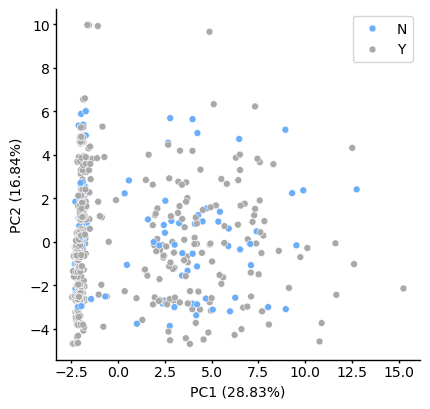

top PC1 loadings: fpocket_Mean_alpha_sphere_Solvent_Acc    0.278978
fpocket_Mean_alpha_sphere_radius         0.275599
fpocket_Num_alpha_spheres                0.269479
fpocket_Pocket_volume_Monte_Carlo        0.265859
fpocket_Amino_Acid_based_volume_Score    0.262726
total_sasa                               0.255497
fpocket_Hydrophobicity_Score             0.251059
apolar_sasa                              0.249731
fpocket_Pocket_volume_convex_hull        0.233058
fpocket_Num_apolar_alpha_sphere          0.229815
Name: PC1, dtype: float64
top PC2 loadings: overall_ligandRMSD_std            0.332801
overall_ligandRMSD_mean           0.321279
entry_overall_std_proteinRMSD     0.312268
boltz_chai_std_ligandRMSD         0.312134
boltz_chai_mean_ligandRMSD        0.300867
boltz-chai_std_proteinRMSD        0.298160
boltz_boltz_mean_ligandRMSD       0.284500
entry_overall_mean_proteinRMSD    0.275174
boltz-chai_mean_proteinRMSD       0.269052
boltz_boltz_std_ligandRMSD        0.261335
Name: PC

/tmp/ipykernel_1572387/2541183670.py:23: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_normalized[feature_columns] = df_normalized[feature_columns].fillna(0)


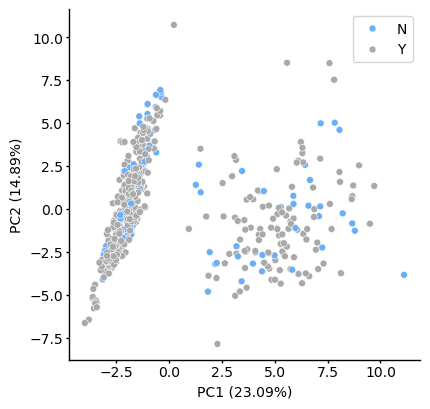

top PC1 loadings: fpocket_Mean_alpha_sphere_radius         0.276693
total_sasa                               0.274042
fpocket_Mean_alpha_sphere_Solvent_Acc    0.273655
fpocket_Amino_Acid_based_volume_Score    0.273009
fpocket_Pocket_volume_Monte_Carlo        0.268981
fpocket_Num_alpha_spheres                0.266294
apolar_sasa                              0.265142
fpocket_Hydrophobicity_Score             0.263095
polar_sasa                               0.253836
fpocket_Pocket_volume_convex_hull        0.245701
Name: PC1, dtype: float64
top PC2 loadings: overall_ligandRMSD_std            0.321921
overall_ligandRMSD_mean           0.319570
boltz_chai_mean_ligandRMSD        0.307503
boltz_chai_std_ligandRMSD         0.291100
boltz_boltz_mean_ligandRMSD       0.263393
boltz_boltz_std_ligandRMSD        0.249612
entry_overall_std_proteinRMSD     0.228419
boltz-chai_std_proteinRMSD        0.225661
boltz-chai_mean_proteinRMSD       0.194626
entry_overall_mean_proteinRMSD    0.184209
Name: PC

In [4]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt


label_column = 'Activity'
dPALETTE_grey_blue = ["#6baef7", "darkgrey"]

def visualize_PCA(df, feature_columns, missing_columns, label_column, tool, note, set_NaN_zero = False, ):
    label_column = label_column

    s2 = set(missing_columns)        
    feature_columns = [x for x in feature_columns if x not in s2]

    if tool == None: 
        df_normalized = df.loc[:,feature_columns + [label_column]].copy()
    else: 
        df_normalized = df.loc[df["tool"] == tool, feature_columns + [label_column]].copy()
    if set_NaN_zero == True: 
        df_normalized[feature_columns] = df_normalized[feature_columns].fillna(0)

    df_normalized.dropna(inplace=True)
    feature_columns = [c for c in feature_columns if c in df_normalized.columns]
    X = df_normalized[feature_columns].to_numpy()  
    y = df_normalized[label_column].to_numpy()    

    # standardize features using standard normalization i.e. mean=0 and variance=1
    scaler = StandardScaler()
    X_scaled  = scaler.fit_transform(X)

    # PCA
    pca = PCA(n_components=2, svd_solver="full", random_state=0)
    X_pca = pca.fit_transform(X_scaled)   

    # plot
    pca_df = pd.DataFrame({"PC1": X_pca[:, 0], "PC2": X_pca[:, 1], label_column: y})
    exp_var_pct = pca.explained_variance_ratio_ * 100

    plt.figure(figsize=(4.4, 4.2))
    ax = sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue=label_column, alpha = 1, s=25, palette=dPALETTE_grey_blue)
    ax.set_xlabel(f"PC1 ({exp_var_pct[0]:.2f}%)")
    ax.set_ylabel(f"PC2 ({exp_var_pct[1]:.2f}%)")
    #ax.set_title(f"PCA of standardized features ({tool} - {note})")
    clean_plt(ax) 
    plt.legend(frameon=True, loc = 'upper right', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.savefig(f'/nvme2/helen/masterthesis/3_manuscript/figures/PCA_overview_DEDB_{tool}_{note.replace(" ", "_")}.png', dpi=300)
    plt.show()
    

    # extract loadings

    # Loadings: each row is a PC, each column a feature
    loadings = pd.DataFrame(
        pca.components_.T, 
        index=feature_columns, 
        columns=[f'PC{i+1}' for i in range(pca.n_components_)]
    )

    # sort by absolute contribution
    top_PC1 = loadings['PC1'].abs().sort_values(ascending=False).head(10)
    top_PC2 = loadings['PC2'].abs().sort_values(ascending=False).head(10)
    print(f'top PC1 loadings: {top_PC1}')
    print(f'top PC2 loadings: {top_PC2}')


visualize_PCA(results_df, feature_columns, missing_columns_chai, 'Activity', 'chai', 'first structures only', set_NaN_zero=True)
visualize_PCA(results_df, feature_columns, missing_columns_boltz, 'Activity', 'boltz', 'first structures only', set_NaN_zero=True)


/tmp/ipykernel_1572387/1816421516.py:23: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_normalized[feature_columns] = df_normalized[feature_columns].fillna(0)


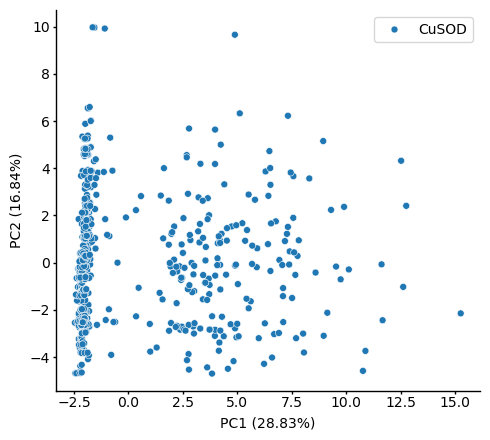

Top PC1 loadings:
 fpocket_Mean_alpha_sphere_Solvent_Acc    0.278978
fpocket_Mean_alpha_sphere_radius         0.275599
fpocket_Num_alpha_spheres                0.269479
fpocket_Pocket_volume_Monte_Carlo        0.265859
fpocket_Amino_Acid_based_volume_Score    0.262726
total_sasa                               0.255497
fpocket_Hydrophobicity_Score             0.251059
apolar_sasa                              0.249731
fpocket_Pocket_volume_convex_hull        0.233058
fpocket_Num_apolar_alpha_sphere          0.229815
Name: PC1, dtype: float64
Top PC2 loadings:
 overall_ligandRMSD_std            0.332801
overall_ligandRMSD_mean           0.321279
entry_overall_std_proteinRMSD     0.312268
boltz_chai_std_ligandRMSD         0.312134
boltz_chai_mean_ligandRMSD        0.300867
boltz-chai_std_proteinRMSD        0.298160
boltz_boltz_mean_ligandRMSD       0.284500
entry_overall_mean_proteinRMSD    0.275174
boltz-chai_mean_proteinRMSD       0.269052
boltz_boltz_std_ligandRMSD        0.261335
Name: 

In [5]:
def visualize_PCA(
    df, feature_columns, missing_columns, label_column,
    tool, note, set_NaN_zero=False, color_by=None
):
    label_column = label_column

    # remove missing columns
    s2 = set(missing_columns)        
    feature_columns = [x for x in feature_columns if x not in s2]

    # subset by tool or not
    if tool is None: 
        df_normalized = df.loc[:, feature_columns + [label_column]].copy()
    else: 
        df_normalized = df.loc[df["tool"] == tool, feature_columns + [label_column]].copy()

    # include extra color column (enzyme) if needed
    if color_by is not None and color_by in df.columns:
        df_normalized[color_by] = df.loc[df_normalized.index, color_by]

    # handle NaN
    if set_NaN_zero:
        df_normalized[feature_columns] = df_normalized[feature_columns].fillna(0)

    df_normalized.dropna(inplace=True)
    feature_columns = [c for c in feature_columns if c in df_normalized.columns]

    # extract X, y
    X = df_normalized[feature_columns].to_numpy()
    
    if color_by is None:
        y = df_normalized[label_column].to_numpy()
        hue_col = label_column
        palette = dPALETTE_grey_blue
    else:
        y = df_normalized[color_by].astype(str).to_numpy()
        hue_col = color_by
        # categorical palette for enzymes
        num_classes = y.nunique() if hasattr(y, "nunique") else len(set(y))
        palette = sns.color_palette("tab10", num_classes)

    # scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # PCA
    pca = PCA(n_components=2, svd_solver="full", random_state=0)
    X_pca = pca.fit_transform(X_scaled)

    # build PCA dataframe
    pca_df = pd.DataFrame({
        "PC1": X_pca[:, 0],
        "PC2": X_pca[:, 1],
        hue_col: y
    })

    exp_var_pct = pca.explained_variance_ratio_ * 100

    # --- Plot ---
    plt.figure(figsize=(5, 4.5))
    ax = sns.scatterplot(
        data=pca_df,
        x="PC1", y="PC2",
        hue=hue_col,
        alpha=1, s=25,
        palette=palette
    )
    ax.set_xlabel(f"PC1 ({exp_var_pct[0]:.2f}%)")
    ax.set_ylabel(f"PC2 ({exp_var_pct[1]:.2f}%)")

    clean_plt(ax)
    plt.legend(frameon=True, loc='upper right', bbox_to_anchor=(1, 1))
    plt.tight_layout()

    # create filename label
    extra = f"_colored_by_{hue_col}" if color_by is not None else ""
    fname = f"/nvme2/helen/masterthesis/3_manuscript/figures/PCA_overview_DEDB_{tool}_{note.replace(' ', '_')}{extra}.png"
    
    plt.savefig(fname, dpi=300)
    plt.show()

    # loadings
    loadings = pd.DataFrame(
        pca.components_.T,
        index=feature_columns,
        columns=[f"PC{i+1}" for i in range(pca.n_components_)]
    )
    print("Top PC1 loadings:\n", loadings["PC1"].abs().sort_values(ascending=False).head(10))
    print("Top PC2 loadings:\n", loadings["PC2"].abs().sort_values(ascending=False).head(10))


visualize_PCA(
    results_df,
    feature_columns,
    missing_columns_chai,
    'Activity',
    'chai',
    'first structures only',
    set_NaN_zero=True,
    color_by="enzyme"
)


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings 

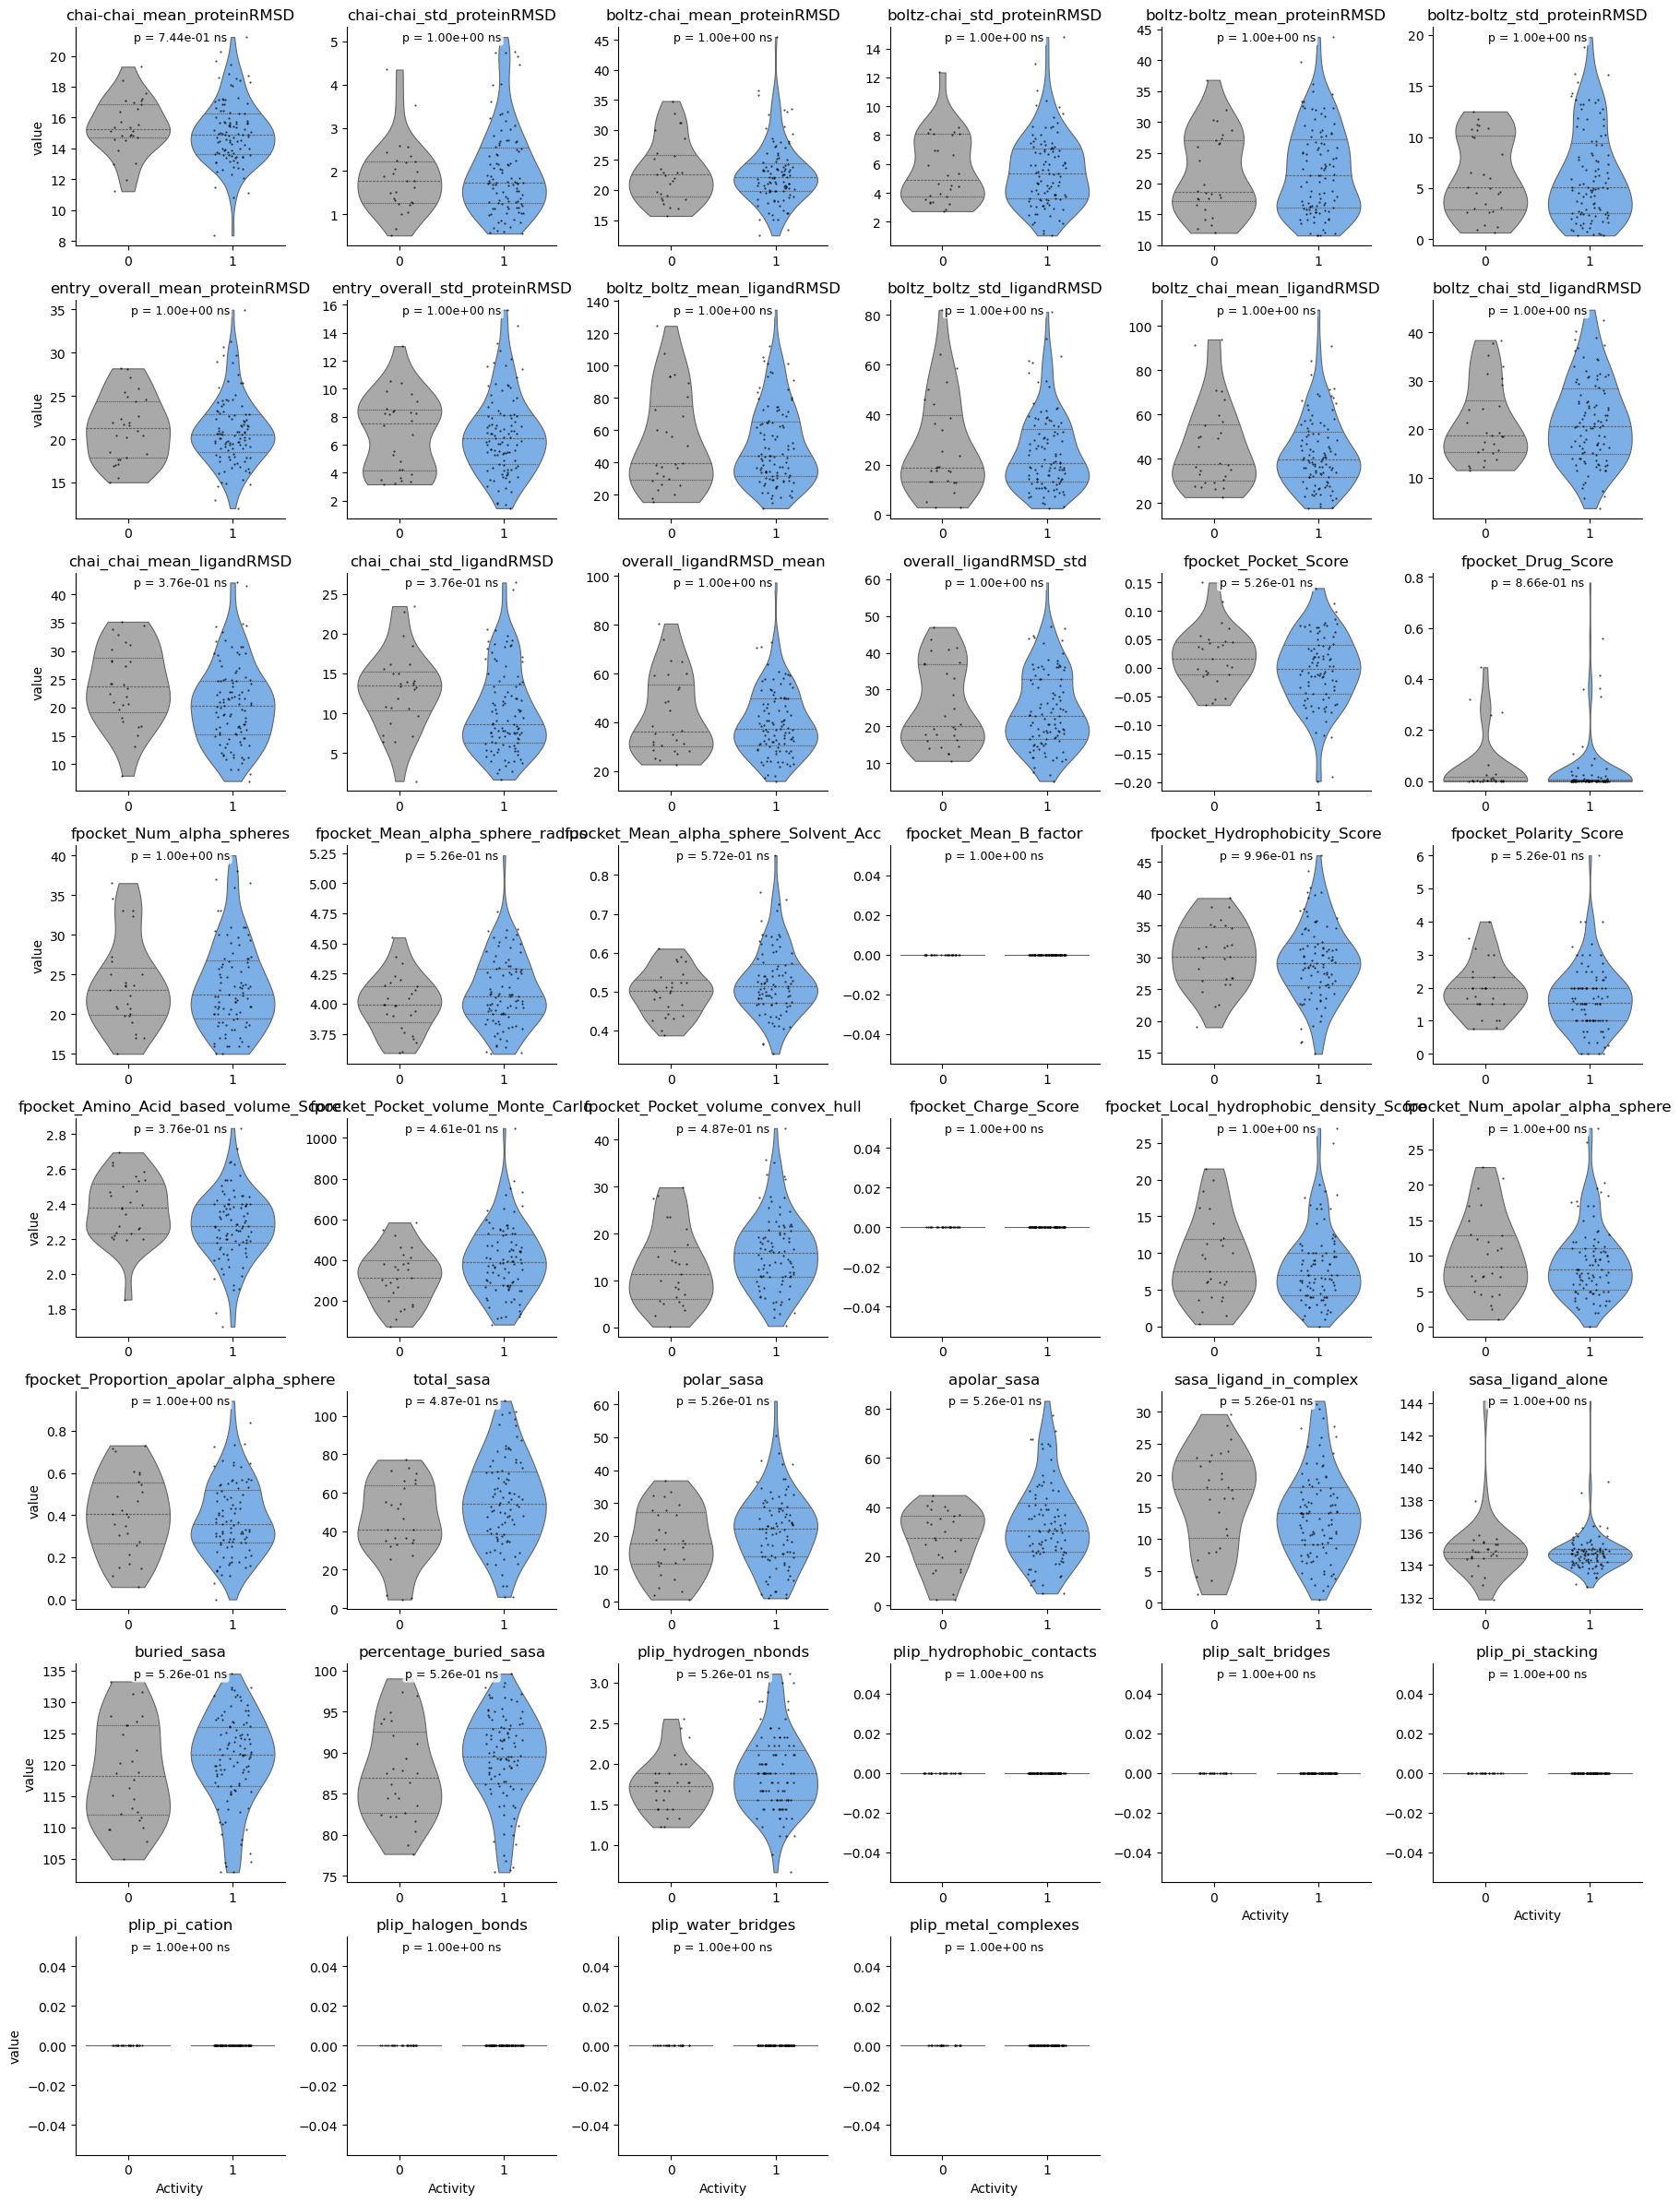

                                  feature   p_value
12              chai_chai_mean_ligandRMSD  0.376267
13               chai_chai_std_ligandRMSD  0.376267
24  fpocket_Amino_Acid_based_volume_Score  0.376267
25      fpocket_Pocket_volume_Monte_Carlo  0.461312
26      fpocket_Pocket_volume_convex_hull  0.486608


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import textwrap as tw

# stats
from scipy.stats import mannwhitneyu, ttest_ind, kruskal
try:
    from statsmodels.stats.multitest import multipletests
    _has_statsmodels = True
except Exception:
    _has_statsmodels = False




def _format_p(p):
    if p is None or np.isnan(p):
        return "p = n/a"
    if p < 1e-4:
        return "p < 1e-4 ***"
    stars = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
    return f"p = {p:.2e} {stars}"

def violin_all_vs_Activity_with_p(
    df, feature_columns, label_col="Activity",
    col_wrap=4, height=3,
    overlay_jitter=0.18, overlay_size=1.6, overlay_alpha=0.7,
    test="mannwhitney",            # 'mannwhitney' | 'ttest' | 'auto'
    adjust="fdr_bh"                # 'fdr_bh' | None
):
    """
    Violin plots per feature vs. label with raw-point overlay and per-feature p-value.
    - For 2 classes: Mann–Whitney (default) or t-test if test='ttest'
    - For >2 classes: Kruskal–Wallis
    - adjust='fdr_bh' applies Benjamini–Hochberg (requires statsmodels)
    """

    df = df.copy()
    df[label_col] = df[label_col].astype("category")

    # Long format
    df_long = (
        df[feature_columns + [label_col]]
        .melt(id_vars=[label_col], var_name="feature", value_name="value")
        .dropna(subset=["value"])
    )

    df_long["value"] = pd.to_numeric(df_long["value"], errors="coerce")


    # Colors
    try:
        blue = pu.pastel_blue
    except Exception:
        blue = "#6baef7"

    cats = pd.Categorical(df_long[label_col]).categories.tolist()
    if len(cats) == 2:
        palette_map = {cats[0]: "darkgrey", cats[1]: blue}
    else:
        # fallback palette for multi-class
        palette_map = sns.color_palette("tab10", n_colors=len(cats))

    # ---- compute p-values per feature ----
    pvals = {}
    features_present = df_long["feature"].unique().tolist()

    for feat in features_present:
        sub = df_long.loc[df_long["feature"] == feat]
        groups = [sub.loc[sub[label_col] == c, "value"].dropna().values for c in cats]
        # drop empty groups
        groups = [g for g in groups if len(g) > 0]

        p = np.nan
        if len(groups) == 2:
            a, b = groups
            if len(a) > 0 and len(b) > 0:
                if test == "ttest":
                    p = ttest_ind(a, b, equal_var=False, nan_policy="omit").pvalue
                elif test == "auto":
                    # heuristic: if both groups fairly large and look normal-ish you might choose ttest;
                    # we keep it simple and use MWU:
                    p = mannwhitneyu(a, b, alternative="two-sided").pvalue
                else:
                    p = mannwhitneyu(a, b, alternative="two-sided").pvalue
        elif len(groups) > 2:
            # Kruskal–Wallis for k>2
            try:
                p = kruskal(*groups, nan_policy="omit").pvalue
            except Exception:
                p = np.nan

        pvals[feat] = p

    # Optional multiple testing correction
    if adjust and _has_statsmodels:
        feats = list(pvals.keys())
        raw = np.array([pvals[f] if pvals[f] is not None else np.nan for f in feats], dtype=float)
        mask = ~np.isnan(raw)
        if mask.sum() > 0:
            _, p_adj, _, _ = multipletests(raw[mask], method=adjust)
            for f, padj in zip(np.array(feats)[mask], p_adj):
                pvals[f] = float(padj)
    elif adjust and not _has_statsmodels:
        print("Warning: statsmodels not available; skipping multiple-testing correction.")

    # ---- plot violins ----
    g = sns.catplot(
        data=df_long,
        x=label_col, y="value",
        col="feature", col_wrap=col_wrap,
        kind="violin",
        hue=label_col,
        palette=palette_map,
        dodge=False,
        inner="quartile",
        cut=0,
        linewidth=0.8,
        height=height,
        sharex=True, sharey=False,
        legend=False
    )

    for key, ax in g.axes_dict.items():
        feat = key if isinstance(key, str) else key[-1]
        wrapped = tw.fill(str(feat).replace("_", " "), width=18)  # adjust width to taste
        ax.set_title(wrapped, fontsize=9, pad=10)

    # overlay raw points in black
    g.map_dataframe(
        sns.stripplot,
        x=label_col, y="value",
        color="black",
        jitter=overlay_jitter,
        size=overlay_size,
        alpha=overlay_alpha,
        dodge=False,
        linewidth=0
    )

    # annotate p on each facet, keep x ticks visible
    for key, ax in g.axes_dict.items():  # key is the facet value of "feature"
        feat = key if isinstance(key, str) else key[-1]
        ax.tick_params(axis='x', labelbottom=True)
        for lbl in ax.get_xticklabels():
            lbl.set_visible(True)
        ax.set_title(feat)

        # place p-value in the top center of the panel
        p = pvals.get(feat, np.nan)
        ax.text(0.5, 0.98, _format_p(p), transform=ax.transAxes,
                ha="center", va="top", fontsize=9,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8))

        # optional cleanup
        try:
            pu.clean_plt(ax)
        except Exception:
            pass

    g.set_axis_labels(label_col, "value")
    plt.tight_layout()
    plt.show()

    # return p-values for reference
    return pd.DataFrame({"feature": list(pvals.keys()), "p_value": list(pvals.values())})\
             .sort_values("p_value", na_position="last")


missing_columns = ['boltz2_affinity_pred_value', 'boltz2_affinity_probability_binary', 'boltz2_affinity_pred_value1', 'boltz2_affinity_probability_binary1', 'boltz2_affinity_pred_value2', 'boltz2_affinity_probability_binary2', 'distance_ligand_to_closest_nuc'
                   'boltz2_chains_ptm', 'boltz2_pair_chains_iptm', 'chai_aggregate_score', 'chai_ptm', 'chai_iptm', 'boltz2_confidence_score', 'boltz2_ptm', 'boltz2_iptm', 'boltz2_ligand_iptm', 'boltz2_protein_iptm', 'boltz2_complex_plddt', 'boltz2_complex_iplddt', 'boltz2_complex_pde', 'boltz2_complex_ipde']

s2 = set(missing_columns)    
feature_columns = [x for x in feature_columns if x not in s2]

pvals_df = violin_all_vs_Activity_with_p(
    results_df_avg_all,
    feature_columns,
    label_col="Activity",
    col_wrap=6,
    height=3,
    test="mannwhitney",   # or 'ttest' or 'auto'
    adjust="fdr_bh"       # or None (requires statsmodels to apply)
)
print(pvals_df.head())


In [7]:
results_df_avg_all

,Entry,chai-chai_mean_proteinRMSD,chai-chai_std_proteinRMSD,chai-vina_mean_proteinRMSD,chai-vina_std_proteinRMSD,boltz-chai_mean_proteinRMSD,boltz-chai_std_proteinRMSD,vina-vina_mean_proteinRMSD,vina-vina_std_proteinRMSD,boltz-vina_mean_proteinRMSD,...,percentage_buried_sasa,plip_hydrogen_nbonds,plip_hydrophobic_contacts,plip_salt_bridges,plip_pi_stacking,plip_pi_cation,plip_halogen_bonds,plip_water_bridges,plip_metal_complexes,Activity
0,0_A0A0D7B0Z6_CuSOD,16.534337,2.242217,NaN,NaN,22.855374,4.663303,NaN,NaN,NaN,...,94.080550,2.555556,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,0_A0A0K0D5V0_CuSOD,15.378015,1.621954,NaN,NaN,21.575833,3.795730,NaN,NaN,NaN,...,87.497498,1.444444,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,0_A0A0R3PEU6_CuSOD,12.667752,0.680195,NaN,NaN,13.332541,1.856554,NaN,NaN,NaN,...,83.303970,1.555556,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,0_A0A183B4Z1_CuSOD,10.822869,1.128497,NaN,NaN,23.082580,4.725497,NaN,NaN,NaN,...,90.048095,1.777778,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,0_A0A183IKQ1_CuSOD,13.975962,1.289068,NaN,NaN,18.888521,1.892750,NaN,NaN,NaN,...,83.594812,1.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126,N64_0p834_CuSOD,13.964233,0.862906,NaN,NaN,17.890633,3.880320,NaN,NaN,NaN,...,89.943963,2.222222,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
127,N731_0p943_CuSOD,15.631632,1.519825,NaN,NaN,27.436982,5.502683,NaN,NaN,NaN,...,94.991366,1.888889,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
128,N738_0p863_CuSOD,15.170293,1.309943,NaN,NaN,21.058826,4.524942,NaN,NaN,NaN,...,88.160262,1.444444,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
129,N74_0p807_CuSOD,17.163190,1.739427,NaN,NaN,33.337023,10.417132,NaN,NaN,NaN,...,88.451111,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


### 5-fold crossvaldidation random forest classifier

[[ 0 10]
 [ 0 34]]
[[ 0  9]
 [ 0 35]]
[[ 0  9]
 [ 0 34]]
   fold  Accuracy        F1       AUC
0     1  0.772727  0.871795  0.536765
1     2  0.795455  0.886076  0.655556
2     3  0.790698  0.883117  0.635621

Mean CV performance:
 fold        2.000000
Accuracy    0.786293
F1          0.880329
AUC         0.609314
dtype: float64


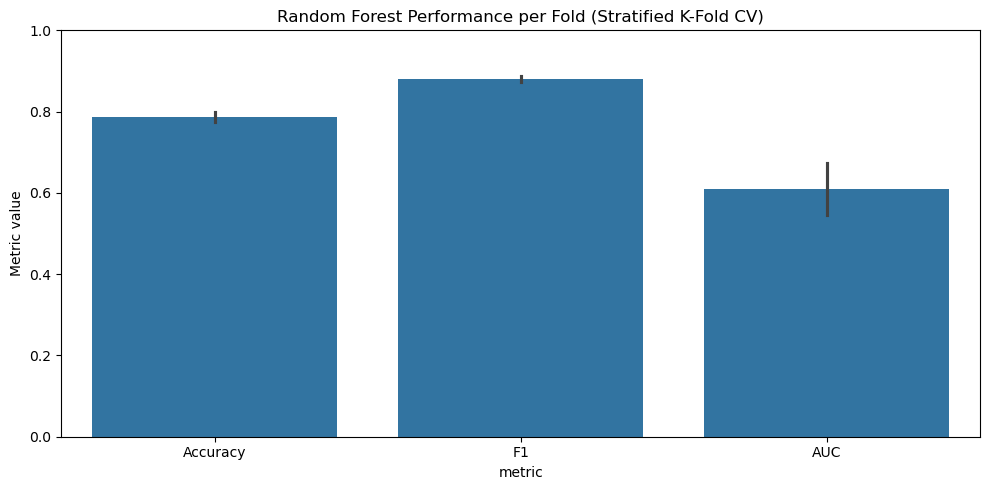

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# make a mapping Entry -> substrate_name (assuming it's consistent per Entry)
entry_to_substrate = (
    results_df[["Entry", "substrate_name"]]
    .drop_duplicates()
    .set_index("Entry")["substrate_name"]
)
# add substrate_name to the averaged df
results_df_avg_all["substrate_name"] = results_df_avg_all["Entry"].map(entry_to_substrate)

X = results_df_avg_all[feature_columns].values
y = results_df_avg_all["Activity"].astype(int).values  # ensure 0/1

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# rf = RandomForestClassifier(
#     n_estimators=500,
#     class_weight="balanced",   # important for your imbalance
#     n_jobs=-1,
#     random_state=42
# )

# rf = RandomForestClassifier(
#     n_estimators=1000,
#     max_depth=None,
#     min_samples_split=2,
#     min_samples_leaf=1,
#     max_features="sqrt",
#     class_weight="balanced",
#     n_jobs=-1,
#     random_state=42
# )

rf = RandomForestClassifier(
    n_estimators=1000,
    class_weight={0: 5, 1: 1},   # manually upweight class 0
    random_state=42,
    n_jobs=-1
)

cv_rows = []
pred_rows = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)
    y_prob = rf.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average="binary")
    auc = roc_auc_score(y_test, y_prob)

    cv_rows.append({
        "fold": fold,
        "Accuracy": acc,
        "F1": f1,
        "AUC": auc
    })

    fold_df = pd.DataFrame({
        "fold": fold,
        "Entry": results_df_avg_all.iloc[test_idx]["Entry"].values,
        "substrate_name": results_df_avg_all.iloc[test_idx]["substrate_name"].values,
        "y_true": y_test,
        "y_pred": y_pred,
        "y_prob": y_prob
    })
    pred_rows.append(fold_df)

    from sklearn.metrics import confusion_matrix
    print(confusion_matrix(y_test, y_pred))


cv_results_df = pd.DataFrame(cv_rows)
predictions_df = pd.concat(pred_rows, ignore_index=True)

print(cv_results_df)
print("\nMean CV performance:\n", cv_results_df.mean(numeric_only=True))



plt.figure(figsize=(10,5))
cv_results_long = cv_results_df.melt(id_vars="fold",
                                     var_name="metric",
                                     value_name="value")

sns.barplot(
    data=cv_results_long,
    x="metric", y="value",
    errorbar="sd"
)
plt.ylim(0,1)
plt.title("Random Forest Performance per Fold (Stratified K-Fold CV)")
plt.ylabel("Metric value")
plt.tight_layout()
plt.show()



In [11]:
import xgboost as xgb
print(xgb.__version__)


3.1.2


scale_pos_weight = 3.6785714285714284


/home/helen/miniconda3/envs/enzymetk/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [23:26:11] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1764148514279/work/src/learner.cc:790: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Fold 1
Predicted classes: (array([0, 1]), array([24,  3]))
Confusion matrix:
 [[20  1]
 [ 4  2]]
Prob range: 0.005978816 0.7057121
Model predicts both classes ✓



/home/helen/miniconda3/envs/enzymetk/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [23:27:26] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1764148514279/work/src/learner.cc:790: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Fold 2
Predicted classes: (array([0, 1]), array([24,  2]))
Confusion matrix:
 [[20  0]
 [ 4  2]]
Prob range: 0.0036052181 0.8452837
Model predicts both classes ✓



...


Fold 3
Predicted classes: (array([0, 1]), array([22,  4]))
Confusion matrix:
 [[17  3]
 [ 5  1]]
Prob range: 0.0005396005 0.95892537
Model predicts both classes ✓



/home/helen/miniconda3/envs/enzymetk/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [23:30:17] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1764148514279/work/src/learner.cc:790: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Fold 4
Predicted classes: (array([0, 1]), array([21,  5]))
Confusion matrix:
 [[17  4]
 [ 4  1]]
Prob range: 0.0035196133 0.87338966
Model predicts both classes ✓



/home/helen/miniconda3/envs/enzymetk/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [23:31:48] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1764148514279/work/src/learner.cc:790: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.



Fold 5
Predicted classes: (array([0, 1]), array([20,  6]))
Confusion matrix:
 [[18  3]
 [ 2  3]]
Prob range: 0.0008611115 0.8844554
Model predicts both classes ✓


Cross-validation results:
   fold  Accuracy        F1       AUC
0     1  0.814815  0.444444  0.626984
1     2  0.846154  0.500000  0.625000
2     3  0.692308  0.200000  0.508333
3     4  0.692308  0.200000  0.571429
4     5  0.807692  0.545455  0.723810

Mean performance:
 fold        3.000000
Accuracy    0.770655
F1          0.377980
AUC         0.611111
dtype: float64


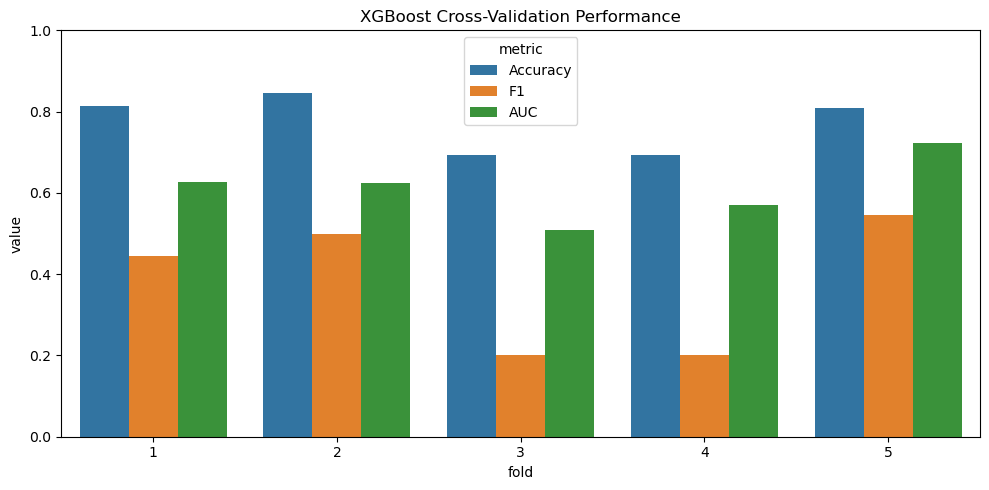

In [17]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import pandas as pd
import numpy as np

# Prepare data
X = results_df_avg_all[feature_columns].values
y = results_df_avg_all["Activity"].astype(int).values
y = (results_df_avg_all["Activity"] == 0).astype(int)


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# imbalance handling
pos = np.sum(y == 1)
neg = np.sum(y == 0)
scale_weight = neg / pos if pos > 0 else 1.0

print("scale_pos_weight =", scale_weight)

# XGBoost classifier
xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_weight,
    tree_method="hist",    
    predictor="gpu_predictor",  # <- GPU inference
    random_state=42
)

cv_rows = []
pred_rows = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    xgb.fit(X_train, y_train)

    y_pred = xgb.predict(X_test)
    y_prob = xgb.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    cv_rows.append({
        "fold": fold,
        "Accuracy": acc,
        "F1": f1,
        "AUC": auc
    })

    fold_df = pd.DataFrame({
        "fold": fold,
        "Entry": results_df_avg_all.iloc[test_idx]["Entry"].values,
        "substrate_name": results_df_avg_all.iloc[test_idx]["substrate_name"].values,
        "y_true": y_test,
        "y_pred": y_pred,
        "y_prob": y_prob
    })
    pred_rows.append(fold_df)

    print("\n==============================")
    print(f"Fold {fold}")

    # Class distribution of predictions
    print("Predicted classes:", np.unique(y_pred, return_counts=True))

    # Confusion matrix
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

    # Probability range
    print("Prob range:", y_prob.min(), y_prob.max())

    # Check default threshold degeneracy
    if len(np.unique(y_pred)) == 1:
        print("Degenerate predictor: model is predicting only class", np.unique(y_pred)[0])
    else:
        print("Model predicts both classes ✓")
    print("==============================\n")


cv_results_df = pd.DataFrame(cv_rows)
predictions_df = pd.concat(pred_rows, ignore_index=True)

print("\nCross-validation results:")
print(cv_results_df)
print("\nMean performance:\n", cv_results_df.mean(numeric_only=True))

import seaborn as sns
import matplotlib.pyplot as plt

cv_results_long = cv_results_df.melt(id_vars="fold", 
                                     var_name="metric", 
                                     value_name="value")

plt.figure(figsize=(10,5))
sns.barplot(data=cv_results_long, x="fold", y="value", hue="metric")
plt.ylim(0,1)
plt.title("XGBoost Cross-Validation Performance")
plt.tight_layout()
plt.show()


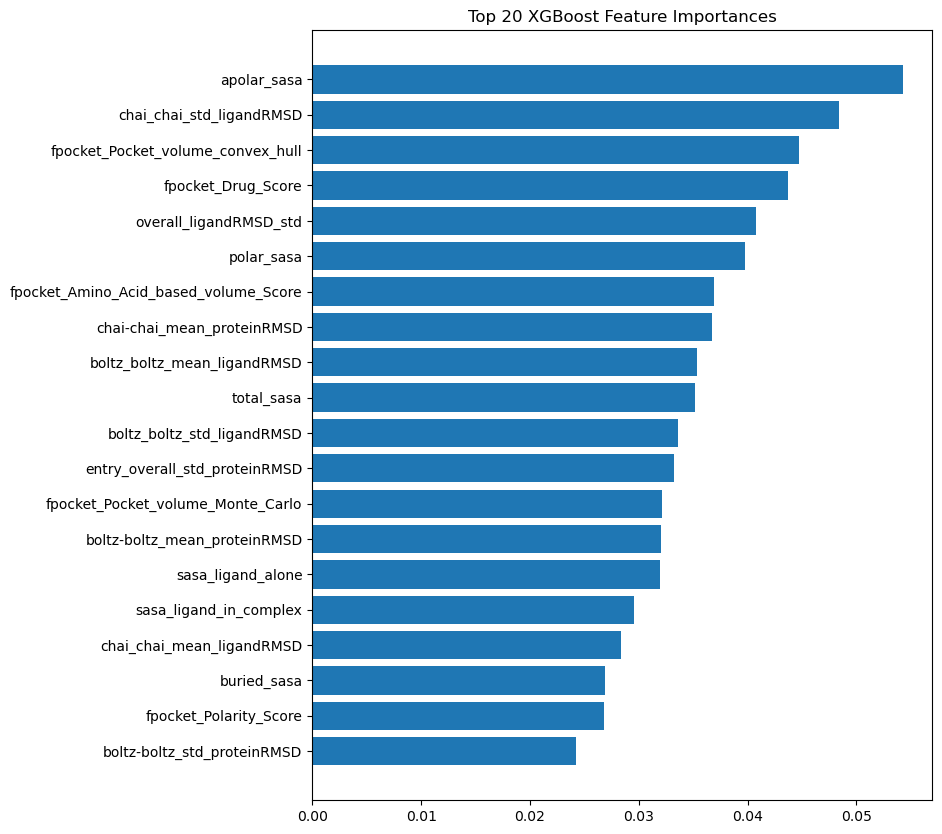

In [18]:
import matplotlib.pyplot as plt
import numpy as np

importances = xgb.feature_importances_
idx = np.argsort(importances)[::-1]

plt.figure(figsize=(8,10))
plt.barh(np.array(feature_columns)[idx][:20], importances[idx][:20])
plt.gca().invert_yaxis()
plt.title("Top 20 XGBoost Feature Importances")
plt.show()
